# 1     Pre-Setting, Imports and Data Loading
## 1.1 Modules

In [33]:
from tokenize import group

# ======================= Module Imports ============================= #

# ========== Base Modules
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel
from datetime import datetime
import time
import numpy as np
import os
from pathlib import Path
from my_dataset import Flickr8kDataset
from torchvision import transforms # for image transformations
import pandas as pd # for data handling
from PIL import Image # for image processing
import matplotlib.pyplot as plt # for visualization
from sklearn.model_selection import train_test_split # for splitting dataset


import re # for regex operations to analyze captions
from collections import Counter # to count word frequencies



In [34]:
# helperfunctions

# find project root
def find_project_root(start: Path = Path.cwd()):
    """Find the project root directory by looking for common markers."""
    # look for common project markers and return the first match
    for p in [start] + list(start.parents):
        if (p / 'data').exists() or (p / '.git').exists() or (p / 'pyproject.toml').exists():
            return p.resolve()
    return Path.cwd().resolve()

# compile model filename
def compile_filename(device, batch, epochs, lr, description):
    today = datetime.now().strftime("%Y%m%d")
    file_name = f"{today}_clip_{device}_bs{batch}_ep{epochs}_lr{lr}_{description}.pth"
    return file_name



## 1.2 Funcitonality Pre-settings

In [35]:
# Define dynamic paths
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # fallback for Jupyter notebooks
    PROJECT_ROOT = find_project_root()

# PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
IMG_DIR = DATA_DIR / "Images"
CAPTIONS_FILE = DATA_DIR / "flickr8k_captions.csv"
RUNS_DIR = PROJECT_ROOT / "runs"


# Finetuning flag
finetuning = True

# model saving flag
save_model = True

# DataLoader and subset parameters
use_subset = True
subset_size = 500  # Number of samples in subset
batch_size = 32
num_workers = 0  # for DataLoader




In [36]:
# Load Dataset
# CSV laden
captions = pd.read_csv(CAPTIONS_FILE, sep=";", engine="python")

# # Preprocessing if necessary
# preprocess = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
# ])

# length of dataset
dataset_length = len(captions)

# show first 5 entries
captions.head()


,filename,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## 1.3 Data Loading


# 2 Data Analysis and Visualization
## 2.1 Descrition

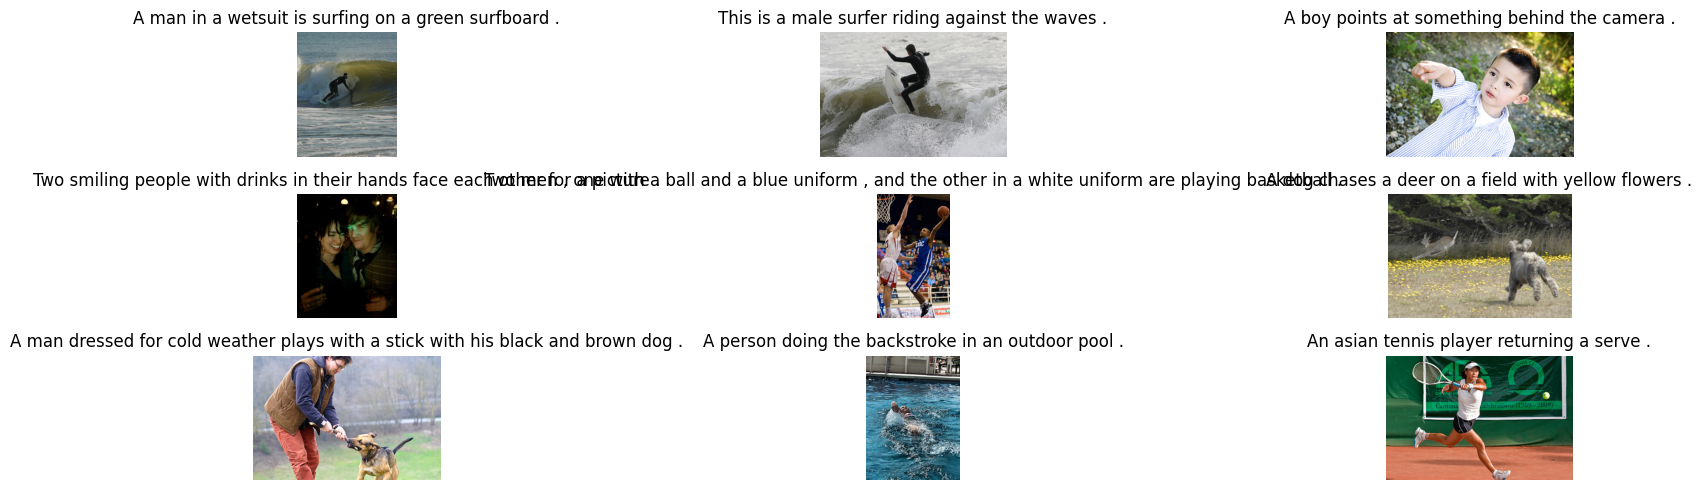

In [37]:
# plot some random images with captions as example
fig, axes = plt.subplots(3, 3, figsize=(20, 5))

# random seed
# np.random.seed(42)

# plot random samples
for ax in axes.ravel():
    row = captions.sample(1).iloc[0]
    img = Image.open(os.path.join(IMG_DIR, row['filename']))
    ax.imshow(img)
    ax.set_title(row['caption'])
    ax.axis('off')

plt.tight_layout()
plt.show()


## 2.2 Image and Caption analysis

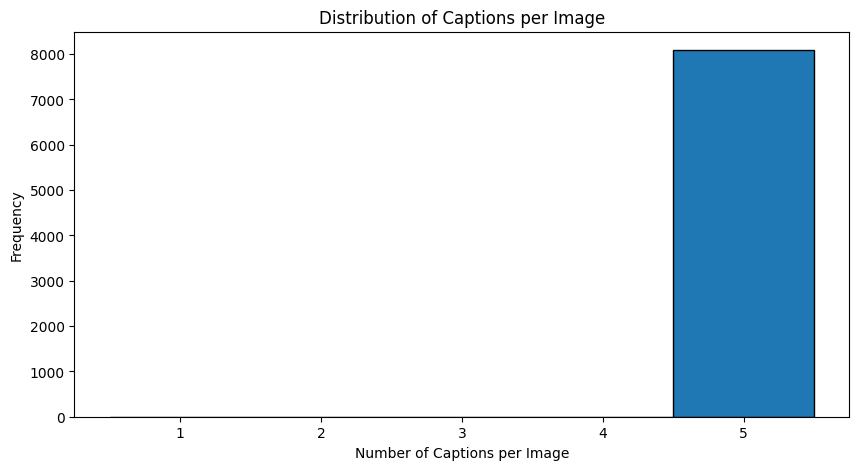

In [38]:
# captions per image

captions_per_image = captions.groupby("filename").size()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(captions_per_image, bins=range(1, captions_per_image.max()+
2), align='left', edgecolor='black')
ax.set_xlabel("Number of Captions per Image")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Captions per Image")
plt.xticks(range(1, captions_per_image.max()+1))
plt.show()



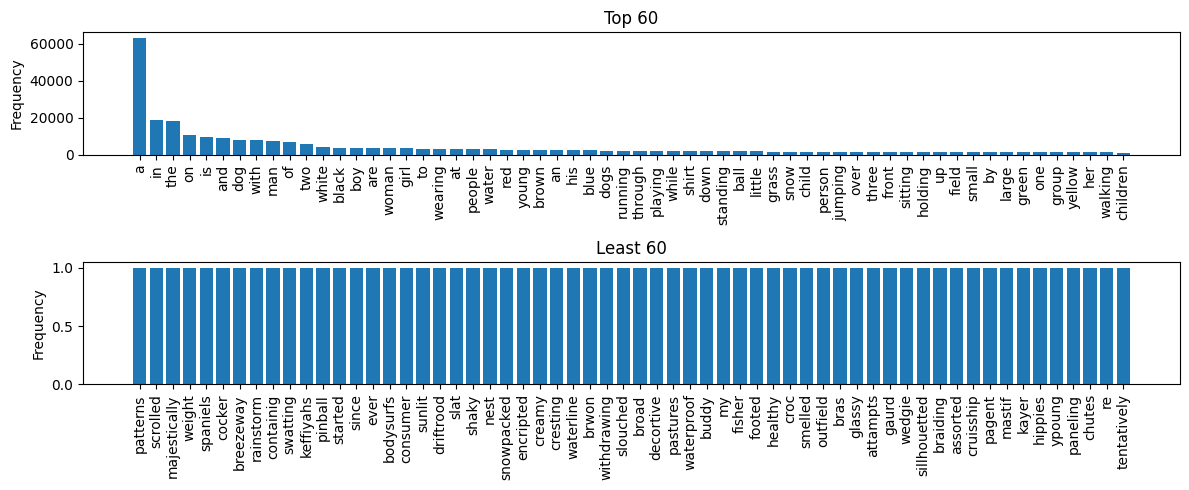

In [39]:
# combine all captions into one large text
text = " ".join(captions["caption"].astype(str)).lower()

# extract words using regex
words = re.findall(r"\b\w+\b", text)

# count word frequencies
freq = Counter(words)

# get the 30 most common and 30 least common words
top30 = freq.most_common(60)
least30 = freq.most_common()[:-61:-1]

# print(top30)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# top: Top 30
axes[0].bar([w for w,_ in top30], [c for _,c in top30])
axes[0].set_title("Top 60")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[1].bar([w for w,_ in least30], [c for _,c in least30])
axes[1].set_title("Least 60")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

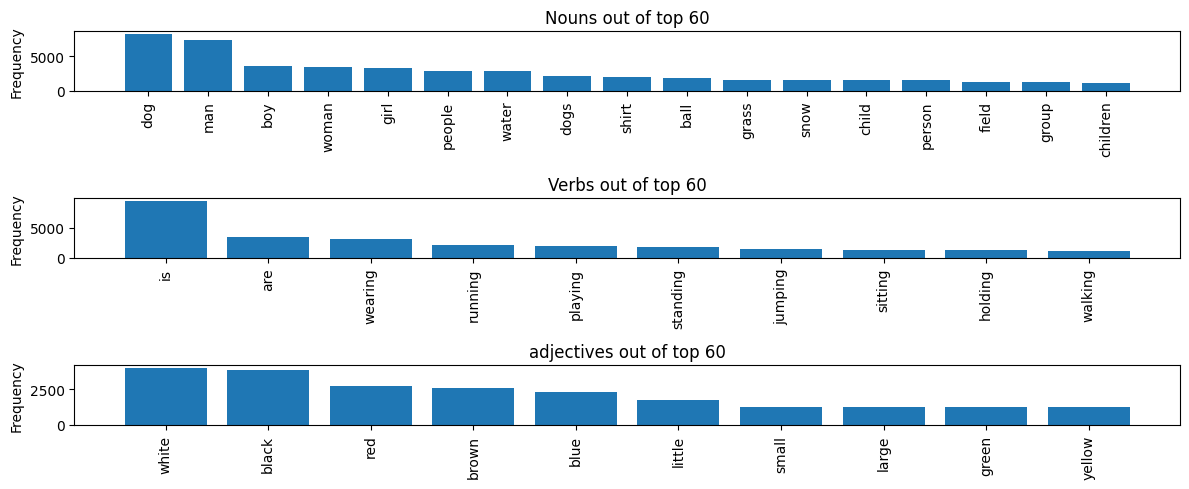

In [40]:
# closer look at nouns, verbs, adjectives in top 60 words
# manually categorized based on common English usage

# top 60 words categorized
top60_nouns = [('dog', 8138), ('man', 7274), ('boy', 3581), ('woman', 3402), ('girl', 3328), ('people', 2883), ('water', 2790), ('dogs', 2125), ('shirt', 1962), ('ball', 1783), ('grass', 1622), ('snow', 1547), ('child', 1545), ('person', 1542), ('field', 1283), ('group', 1218), ('children', 1156)]

top60_verbs = [('is', 9345), ('are', 3504), ('wearing', 3062), ('running', 2073), ('playing', 2008), ('standing', 1787), ('jumping', 1473), ('sitting', 1368), ('holding', 1324), ('walking', 1165)]

top60_adj = [('white', 3959), ('black', 3848), ('red', 2691), ('brown', 2578), ('blue', 2279), ('little', 1768), ('small', 1278), ('large', 1236), ('green', 1234), ('yellow', 1217)]

# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(12, 5))

# top: Top 30
axes[0].bar([w for w,_ in top60_nouns], [c for _,c in top60_nouns])
axes[0].set_title("Nouns out of top 60")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[1].bar([w for w,_ in top60_verbs], [c for _,c in top60_verbs])
axes[1].set_title("Verbs out of top 60")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[2].bar([w for w,_ in top60_adj], [c for _,c in top60_adj])
axes[2].set_title("adjectives out of top 60")
axes[2].set_ylabel("Frequency")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [41]:
# number of unique words
num_unique_words = len(freq)
print(f"Number of unique words in captions: {num_unique_words}")

Number of unique words in captions: 8488


In [42]:
# average caption length
avg_caption_length = sum(len(caption.split()) for caption in captions["caption"]) / dataset_length
print(f"Average caption length: {avg_caption_length:.2f} words")


Average caption length: 11.78 words


Average image size: 397.25 x 457.87 pixels


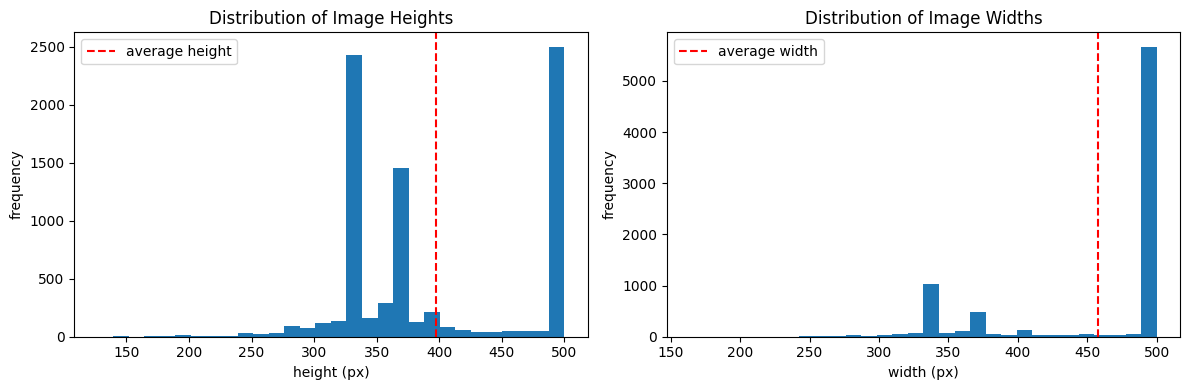

In [43]:
# image proerties
image_sizes = []
for filename in captions["filename"].unique():
    img_path = os.path.join(IMG_DIR, filename)
    with Image.open(img_path) as img:
        image_sizes.append(img.size)
widths, heights = zip(*image_sizes)
avg_width = sum(widths) / len(widths)
avg_height = sum(heights) / len(heights)
print(f"Average image size: {avg_height:.2f} x {avg_width:.2f} pixels")


fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(heights, bins=30)
ax[0].axvline(avg_height, linestyle="--", color = 'red')
ax[0].set_xlabel("height (px)")
ax[0].set_ylabel("frequency")
ax[0].set_title("Distribution of Image Heights")
ax[0].legend(["average height"])

ax[1].hist(widths, bins=30)
ax[1].axvline(avg_width, linestyle="--", color = 'red')
ax[1].set_xlabel("width (px)")
ax[1].set_ylabel("frequency")
ax[1].set_title("Distribution of Image Widths")
ax[1].legend(["average width"])

plt.tight_layout()
plt.show()


# 3 Data Preprocessing

## 3.1 Subset

In [44]:
# dataloader with transformations and subset option
if use_subset:
    unique_images = captions['filename'].unique() # get unique image filenames
    chosen = pd.Series(unique_images).sample(n=subset_size, random_state=42) # randomly choose a subset
    subset = captions[captions['filename'].isin(chosen)].reset_index(drop=True)# filter captions to only include chosen images
    captions = subset.copy()  # update captions to only include subset

# print dataset info
print(captions["filename"].nunique(), "images in dataset")  # number of unique images in subset
print(captions.groupby("filename").size().describe())# number of captions per image in subset
# captions.head() # display first few entries of subset

500 images in dataset
count    500.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
dtype: float64


## 3.2 Dataloader

In [45]:
# create new csv file for subset
date = datetime.now().strftime("%Y%m%d")
subset_captions_file = DATA_DIR / f"{date}_flickr8k_captions_subset_{subset_size}imgs.csv"
captions.to_csv(subset_captions_file, sep=";", index=False)
CAPTIONS_FILE = subset_captions_file

# get unique images for proper splitting
images = captions["filename"].unique()

# split into train, val, test
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)
val_imgs, test_imgs = train_test_split(test_imgs, test_size=0.5, random_state=42)

# filter captions dataframe based on image splits
train_df = captions[captions["filename"].isin(train_imgs)]
val_df   = captions[captions["filename"].isin(val_imgs)]
test_df  = captions[captions["filename"].isin(test_imgs)]


# create datasets
train_dataset = Flickr8kDataset(str(IMG_DIR), train_df)
val_dataset   = Flickr8kDataset(str(IMG_DIR), val_df)
test_dataset  = Flickr8kDataset(str(IMG_DIR), test_df)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)



# 4 Model Building and Training

## 4.1 Loading Pretrained Model

In [50]:
# load pretrained CLIP model and processor
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

# freez Encoder
for param in model.vision_model.parameters():
    param.requires_grad = False
for param in model.text_model.parameters():
    param.requires_grad = False

# optimizer and loss function and other parameters
loss_fn = nn.CrossEntropyLoss()
epochs = 10
lr = 1e-5

if finetuning:
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
else:
    optimizer = optim.AdamW(model.text_model.parameters(), lr=lr)


# move model to device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model.train()



CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,


## 4.2 Training Loop

In [53]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience=5):

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    logs = []

    for epoch in range(num_epochs):
        start = time.time()

        # -------- TRAIN ---------
        model.train()
        train_loss = 0

        for images, texts in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            inputs = processor(images=images, text=texts, padding=True, return_tensors="pt").to(DEVICE)
            outputs = model(**inputs)

            logits_i = outputs.logits_per_image
            logits_t = outputs.logits_per_text

            gt = torch.arange(len(images), device=DEVICE)

            loss = (criterion(logits_i, gt) + criterion(logits_t, gt)) / 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # -------- VAL ---------
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, texts in val_loader:
                inputs = processor(images=images, text=texts, padding=True, return_tensors="pt").to(DEVICE)
                outputs = model(**inputs)

                logits_i = outputs.logits_per_image
                logits_t = outputs.logits_per_text

                gt = torch.arange(len(images), device=DEVICE)
                loss = (criterion(logits_i, gt) + criterion(logits_t, gt)) / 2

                val_loss += loss.item()

        val_loss /= len(val_loader)
        duration = time.time() - start

        logs.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "time_sec": duration
        })

        print(f"Epoch {epoch+1}/{num_epochs}  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_model_state)
    return pd.DataFrame(logs)


logs = train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, patience=5)

KeyboardInterrupt: 

In [54]:
print(logs)

   epoch  train_loss  val_loss   time_sec
0      1    3.677403  3.533828  85.710892
1      2    3.455473  3.460139  64.287286
2      3    3.381857  3.436432  63.347815
3      4    3.330237  3.415056  65.924544
4      5    3.290761  3.402614  63.440948
5      6    3.252869  3.389811  62.242537
6      7    3.214141  3.387499  73.596860
7      8    3.176813  3.383373  64.505694
8      9    3.137558  3.369982  64.762103
9     10    3.100301  3.365041  63.939339


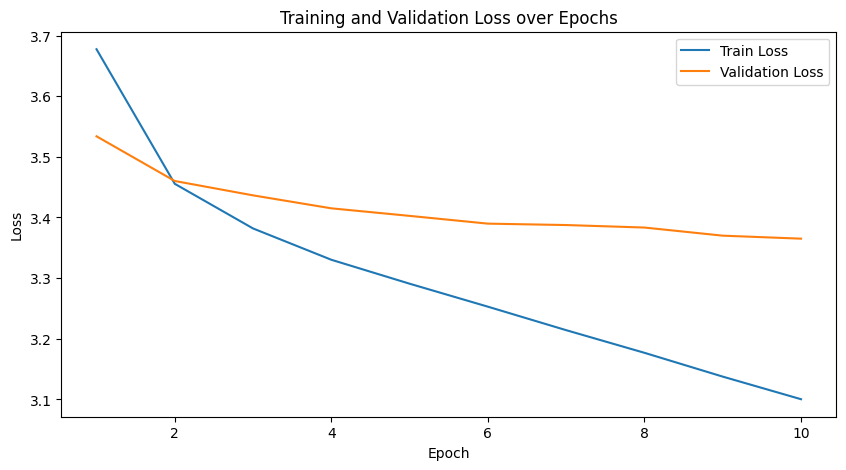

In [55]:
# plot training results
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(logs["epoch"], logs["train_loss"], label="Train Loss")
ax.plot(logs["epoch"], logs["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss over Epochs")
ax.legend()
plt.show()


## 4.3 Hyperparameter Tuning

## 4.4 Saving the Model and export Data

# 5 Evaluation

# 6 Final Remarks